# Teacher goal distribution vs competence

Loads a teacher checkpoint from an experiment directory and visualizes its goal
distribution for a sweep of competence vectors. The maze, the competence goals
and the teacher goal grid are all derived from the experiment's `config.json`
(`ENV_NAME`, `MAZE_SCALE_FACTOR`, `TEACHER_NUM_GOAL_POINTS`).

Competence vector `k` has ones on the `k` competence goals closest to the start
cell (maze BFS distance) and zeros elsewhere, i.e. an increasingly competent
student. `NUM_COMPETENCE_VECTORS` evenly spaced values of `k` in `[0, N]` are used.

Observation inputs match training episode reset (`env.reset` obs, normalized when
`NORMALIZE_ENV`). When the teacher conditions on the student action, the student
bootstrap action at reset is used.

If `DISTILLED_SUBDIR` is set, the distilled teacher trained by `distill_teacher.py`
is evaluated on the same competence vectors and compared to the RL teacher.

In [12]:
import math
import os
from collections import deque
from typing import Any, Optional

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from load_teacher_model import (
    _make_env,
    load_experiment_config,
    load_obs_norm_stats,
    load_student_model,
    load_teacher_model,
    teacher_goal_set_from_config,
)
from envs.ant_maze import RESET
from distill_teacher import build_distill_inputs, load_distilled_teacher

# visuals.py (imported via load_teacher_model) forces the Agg backend.
%matplotlib inline

In [13]:
EXP_DIR = "/network/scratch/f/faisal.mohamed/purejaxrl_simple_teachers/marble_810630496"
CHECKPOINT_DIR = "checkpoints"
SEED = 30
# One of "final", "ema", "avg", "max_log_sum_competence".
CHECKPOINT = "max_log_sum_competence"
NUM_COMPETENCE_VECTORS = 6
NUM_SAMPLES = 1500
# None => use config COMPETENCE_VECTOR_SCALE if present, else 1.0.
COMPETENCE_VECTOR_SCALE = None
MAZE_SIZE_SCALING = 4.0
SAVE_FIGURES = True
OUTPUT_DIR = None
# Distilled teacher subdir under EXP_DIR (from distill_teacher.py); None skips it.
DISTILLED_SUBDIR = "distilled_teacher"

## Config and environment

In [3]:
config = load_experiment_config(EXP_DIR)
goal_grid, num_points, competence_goals, maze_layout = teacher_goal_set_from_config(config)
num_competence = int(competence_goals.shape[0])

if COMPETENCE_VECTOR_SCALE is not None:
    competence_vector_scale = float(COMPETENCE_VECTOR_SCALE)
else:
    competence_vector_scale = float(config.get("COMPETENCE_VECTOR_SCALE", 1.0))

only_on_competence = bool(config.get("TEACHER_CONDITION_ONLY_ON_COMPETENCE", False))
condition_on_competence = (
    bool(config.get("CONDITION_TEACHER_ON_COMPETENCE", True)) or only_on_competence
)
condition_on_action = bool(config.get("CONDITION_TEACHER_ON_ACTION", True))
goal_only = bool(config.get("TEACHER_OBS_GOAL_ONLY", False))

print(f"ENV_NAME={config['ENV_NAME']}  MAZE_SCALE_FACTOR={config.get('MAZE_SCALE_FACTOR', 1)}")
print(f"num competence goals N={num_competence}")
print(f"teacher goal grid: {num_points}x{num_points} = {goal_grid.shape[0]} goals")
print(f"competence_vector_scale={competence_vector_scale:g}")
print(
    f"only_on_competence={only_on_competence} condition_on_competence={condition_on_competence} "
    f"condition_on_action={condition_on_action} goal_only={goal_only}"
)

ENV_NAME=ant_u_maze_single_goal  MAZE_SCALE_FACTOR=1
num competence goals N=7
teacher goal grid: 30x30 = 900 goals
competence_vector_scale=1
only_on_competence=False condition_on_competence=True condition_on_action=False goal_only=False


## Load teacher and reset inputs

In [14]:
assert CHECKPOINT in ("final", "ema", "avg", "max_log_sum_competence"), CHECKPOINT
use_max_log_sum_competence = CHECKPOINT == "max_log_sum_competence"

teacher_train_state = load_teacher_model(
    exp_dir=EXP_DIR,
    checkpoint_dir=CHECKPOINT_DIR,
    seed=SEED,
    use_ema=CHECKPOINT == "ema",
    use_avg=CHECKPOINT == "avg",
    use_max_log_sum_competence=use_max_log_sum_competence,
)
print(f"loaded {CHECKPOINT} teacher (step {int(teacher_train_state.step)})")

distilled_train_state = None
distill_cfg = None
if DISTILLED_SUBDIR is not None:
    distilled_train_state, distill_cfg = load_distilled_teacher(EXP_DIR, DISTILLED_SUBDIR)
    print(
        f"loaded distilled teacher from {DISTILLED_SUBDIR} "
        f"(only_competence_input={distill_cfg['only_competence_input']}, "
        f"recency_weighting={distill_cfg.get('recency_weighting', False)})"
    )


loaded max_log_sum_competence teacher (step 0)
loaded distilled teacher from distilled_teacher (only_competence_input=False, recency_weighting=False)


In [15]:
def _normalize_obs(obs, obs_norm):
    """Apply saved running-mean/var normalization, matching training."""
    if obs_norm is None:
        return obs
    mean, var = obs_norm
    return (obs - jnp.asarray(mean, dtype=obs.dtype)) / jnp.sqrt(
        jnp.asarray(var, dtype=obs.dtype) + 1e-8
    )


def reset_and_normalize_obs(env, env_params, config, *, obs_norm, reset_rng):
    """Reset env with ``reset_rng``; returns ``(norm_obs, raw start_xy)``."""
    raw_obs, _ = env.reset(reset_rng, env_params)
    raw_obs = jnp.asarray(raw_obs, dtype=jnp.float32).reshape(-1)
    start_xy = np.asarray(jax.device_get(raw_obs[:2]), dtype=np.float32)
    if bool(config.get("NORMALIZE_ENV", False)):
        if obs_norm is None:
            raise FileNotFoundError(
                "NORMALIZE_ENV is True but obs_norm_stats.npz was not found; "
                "needed to match training reset observations."
            )
        return _normalize_obs(raw_obs, obs_norm), start_xy
    return raw_obs, start_xy


def sample_bootstrap_action(student_train_state, config, norm_obs, *, seed):
    """Student action at reset with a zero goal appended (if goal-conditioned)."""
    policy_obs = norm_obs
    if bool(config.get("CONDITION_ON_GOAL", False)):
        policy_obs = jnp.concatenate([policy_obs, jnp.zeros((2,), dtype=policy_obs.dtype)])
    pi, _ = student_train_state.apply_fn(student_train_state.params, policy_obs)
    action = pi.sample(seed=jax.random.PRNGKey(seed))
    return jnp.asarray(action, dtype=jnp.float32).reshape(-1)

In [16]:
norm_obs = None
bootstrap_action = None
start_xy = None
distilled_needs_obs = distill_cfg is not None and not distill_cfg["only_competence_input"]
if not only_on_competence or distilled_needs_obs:
    obs_norm = load_obs_norm_stats(EXP_DIR, CHECKPOINT_DIR)
    env, env_params = _make_env(config)
    _, reset_rng = jax.random.split(jax.random.PRNGKey(SEED))
    norm_obs, start_xy = reset_and_normalize_obs(
        env, env_params, config, obs_norm=obs_norm, reset_rng=reset_rng
    )
    if condition_on_action and not only_on_competence:
        # Runs that stop early have no final student; the max-log-sum student
        # was saved at the same time as the latest average teacher.
        use_max_log_sum_student = use_max_log_sum_competence or (
            CHECKPOINT == "avg"
            and not os.path.isdir(os.path.join(EXP_DIR, CHECKPOINT_DIR, "student"))
        )
        student_train_state = load_student_model(
            exp_dir=EXP_DIR,
            checkpoint_dir=CHECKPOINT_DIR,
            seed=SEED,
            use_max_log_sum_competence=use_max_log_sum_student,
        )
        bootstrap_action = sample_bootstrap_action(
            student_train_state, config, norm_obs, seed=SEED + 1
        )
    print(f"reset start_xy={start_xy.tolist()}")
if start_xy is None:
    start_rc = next(
        (i, j)
        for i, row in enumerate(maze_layout)
        for j, cell in enumerate(row)
        if cell == RESET
    )
    start_xy = np.asarray(start_rc, dtype=np.float32) * MAZE_SIZE_SCALING

reset start_xy=[4.0, 4.0]


## Competence vectors

Goals are ordered by BFS distance (in maze cells) from the reset cell; vector `k`
sets the first `k` goals in that order to 1.

In [17]:
def bfs_competence_order(maze_layout, competence_goals, size_scaling=4.0):
    """Indices of ``competence_goals`` sorted by maze BFS distance from the start."""
    rows, cols = len(maze_layout), len(maze_layout[0])
    start = next(
        (i, j) for i in range(rows) for j in range(cols) if maze_layout[i][j] == RESET
    )
    dist = {start: 0}
    queue = deque([start])
    while queue:
        i, j = queue.popleft()
        for di, dj in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            ni, nj = i + di, j + dj
            if (
                0 <= ni < rows
                and 0 <= nj < cols
                and maze_layout[ni][nj] != 1
                and (ni, nj) not in dist
            ):
                dist[(ni, nj)] = dist[(i, j)] + 1
                queue.append((ni, nj))

    cells = np.rint(np.asarray(competence_goals) / size_scaling).astype(int)
    goal_dists = []
    for idx, (i, j) in enumerate(cells):
        if (int(i), int(j)) not in dist:
            raise ValueError(f"competence goal {idx} at cell {(i, j)} is unreachable")
        goal_dists.append(dist[(int(i), int(j))])
    goal_dists = np.asarray(goal_dists)
    order = np.lexsort((np.arange(len(goal_dists)), goal_dists))
    return order, goal_dists


def build_cumulative_ones_contexts(order, num_vectors):
    """Context ``i`` has ones on the first ``ks[i]`` goals of ``order``."""
    n = int(len(order))
    num_vectors = min(int(num_vectors), n + 1)
    ks = np.unique(np.rint(np.linspace(0, n, num_vectors)).astype(int))
    contexts = np.zeros((len(ks), n), dtype=np.float32)
    for row, k in enumerate(ks):
        contexts[row, order[:k]] = 1.0
    return contexts, ks


order, goal_bfs_dists = bfs_competence_order(
    maze_layout, competence_goals, size_scaling=MAZE_SIZE_SCALING
)
contexts, ks = build_cumulative_ones_contexts(order, NUM_COMPETENCE_VECTORS)
print(f"{len(ks)} competence vectors, k = {ks.tolist()}")

6 competence vectors, k = [0, 1, 3, 4, 6, 7]


## Teacher distributions

In [19]:
def build_teacher_inputs(contexts):
    """Teacher inputs for each competence vector; shape ``(num_contexts, D)``."""
    comps = jnp.asarray(contexts, dtype=jnp.float32) * competence_vector_scale
    if only_on_competence:
        return comps
    obs = jnp.asarray(norm_obs)
    if goal_only:
        obs = obs[..., -2:]
    parts = [jnp.broadcast_to(obs, (comps.shape[0], obs.shape[-1]))]
    if condition_on_competence:
        parts.append(comps)
    if condition_on_action:
        parts.append(jnp.broadcast_to(bootstrap_action, (comps.shape[0], bootstrap_action.shape[-1])))
    return jnp.concatenate(parts, axis=-1)


def build_distilled_inputs(contexts):
    """Distilled teacher inputs: ``competence`` or ``concat(base_obs, competence)``."""
    comps = jnp.asarray(contexts, dtype=jnp.float32) * competence_vector_scale
    obs = None
    if not distill_cfg["only_competence_input"]:
        obs = jnp.asarray(norm_obs)[: distill_cfg["base_obs_dim"]]
        obs = jnp.broadcast_to(obs, (comps.shape[0], obs.shape[-1]))
    return build_distill_inputs(obs, comps, distill_cfg["only_competence_input"])


def compute_probs(train_state, inputs):
    """P(goal) per context; shape ``(num_contexts, num_goals)``."""
    pi, _ = train_state.apply_fn(train_state.params, inputs)
    return np.asarray(jax.device_get(pi.probs))


def sample_goal_counts(train_state, inputs, *, num_samples, seed):
    """Sampled goal counts and frequencies per context."""
    pi, _ = train_state.apply_fn(train_state.params, inputs)
    goal_idxs = np.asarray(jax.device_get(pi.sample(seed=jax.random.PRNGKey(seed), sample_shape=(num_samples,))))
    num_goals = goal_grid.shape[0]
    counts = np.stack(
        [np.bincount(goal_idxs[:, c], minlength=num_goals) for c in range(goal_idxs.shape[1])]
    ).astype(np.float32)
    return counts, counts / float(max(num_samples, 1))


teacher_inputs = build_teacher_inputs(contexts)
probs = compute_probs(teacher_train_state, teacher_inputs)
sample_counts, sample_freqs = sample_goal_counts(
    teacher_train_state, teacher_inputs, num_samples=NUM_SAMPLES, seed=SEED + 1
)
print(probs.shape, sample_freqs.shape)

distilled_probs = distilled_sample_counts = distilled_sample_freqs = None
if distilled_train_state is not None:
    distilled_inputs = build_distilled_inputs(contexts)
    distilled_probs = compute_probs(distilled_train_state, distilled_inputs)
    distilled_sample_counts, distilled_sample_freqs = sample_goal_counts(
        distilled_train_state, distilled_inputs, num_samples=NUM_SAMPLES, seed=SEED + 1
    )
    print("distilled", distilled_probs.shape, distilled_sample_freqs.shape)


(6, 900) (6, 900)
distilled (6, 900) (6, 900)


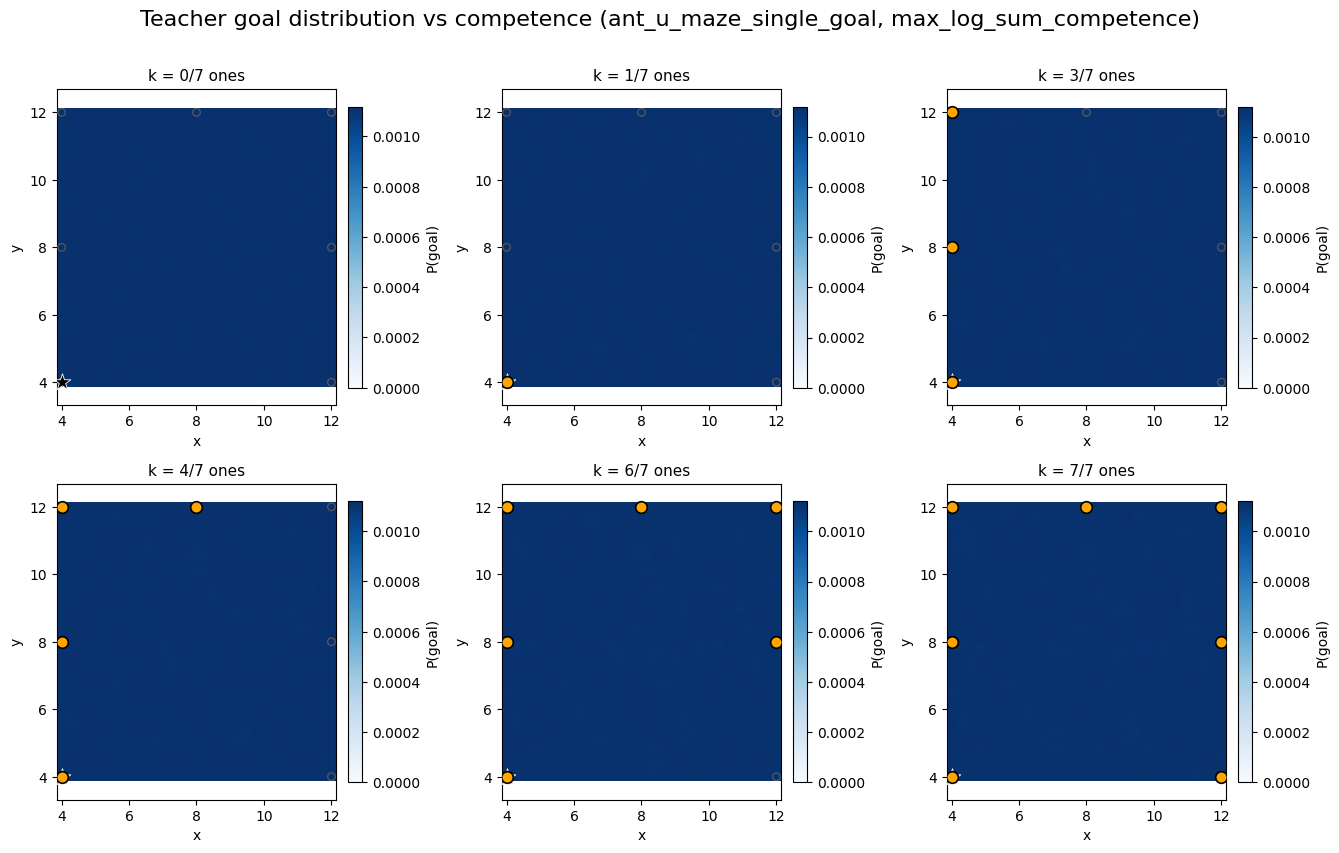

In [20]:
def plot_probs_on_ax(ax, values, *, vmax, competence):
    """Draw a single teacher goal-distribution heatmap on ``ax``."""
    gx = goal_grid[:, 0].reshape(num_points, num_points)
    gy = goal_grid[:, 1].reshape(num_points, num_points)
    mesh = ax.pcolormesh(
        gx, gy, np.asarray(values).reshape(num_points, num_points),
        shading="nearest", cmap="Blues", vmin=0.0, vmax=vmax,
    )
    ax.scatter(
        start_xy[0], start_xy[1], s=160, marker="*", c="black",
        edgecolors="white", linewidths=0.6, zorder=4,
    )
    ax.scatter(
        competence_goals[:, 0], competence_goals[:, 1], s=30, marker="o",
        facecolors="none", edgecolors="0.35", linewidths=0.9, zorder=3,
    )
    active = np.asarray(competence) > 1e-6
    if np.any(active):
        ax.scatter(
            competence_goals[active, 0], competence_goals[active, 1], s=70,
            marker="o", c="orange", edgecolors="black", linewidths=1.2, zorder=5,
        )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="datalim")
    return mesh


def render_context_sweep_figure(values, *, colorbar_label, suptitle):
    """Subplot grid of per-goal values; each panel has its own color scale."""
    num_contexts = int(values.shape[0])
    ncols = int(math.ceil(math.sqrt(num_contexts)))
    nrows = int(math.ceil(num_contexts / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.2 * nrows), squeeze=False)
    for i in range(num_contexts):
        ax = axes[i // ncols][i % ncols]
        vmax = float(np.max(values[i])) if values[i].size else 1.0
        mesh = plot_probs_on_ax(ax, values[i], vmax=vmax if vmax > 0 else 1.0, competence=contexts[i])
        fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04, label=colorbar_label)
        ax.set_title(f"k = {ks[i]}/{num_competence} ones", fontsize=11)
    for j in range(num_contexts, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")
    fig.suptitle(suptitle, fontsize=16, y=1.01)
    fig.tight_layout()
    return fig


probs_fig = render_context_sweep_figure(
    probs, colorbar_label="P(goal)",
    suptitle=f"Teacher goal distribution vs competence ({config['ENV_NAME']}, {CHECKPOINT})",
)
plt.show()

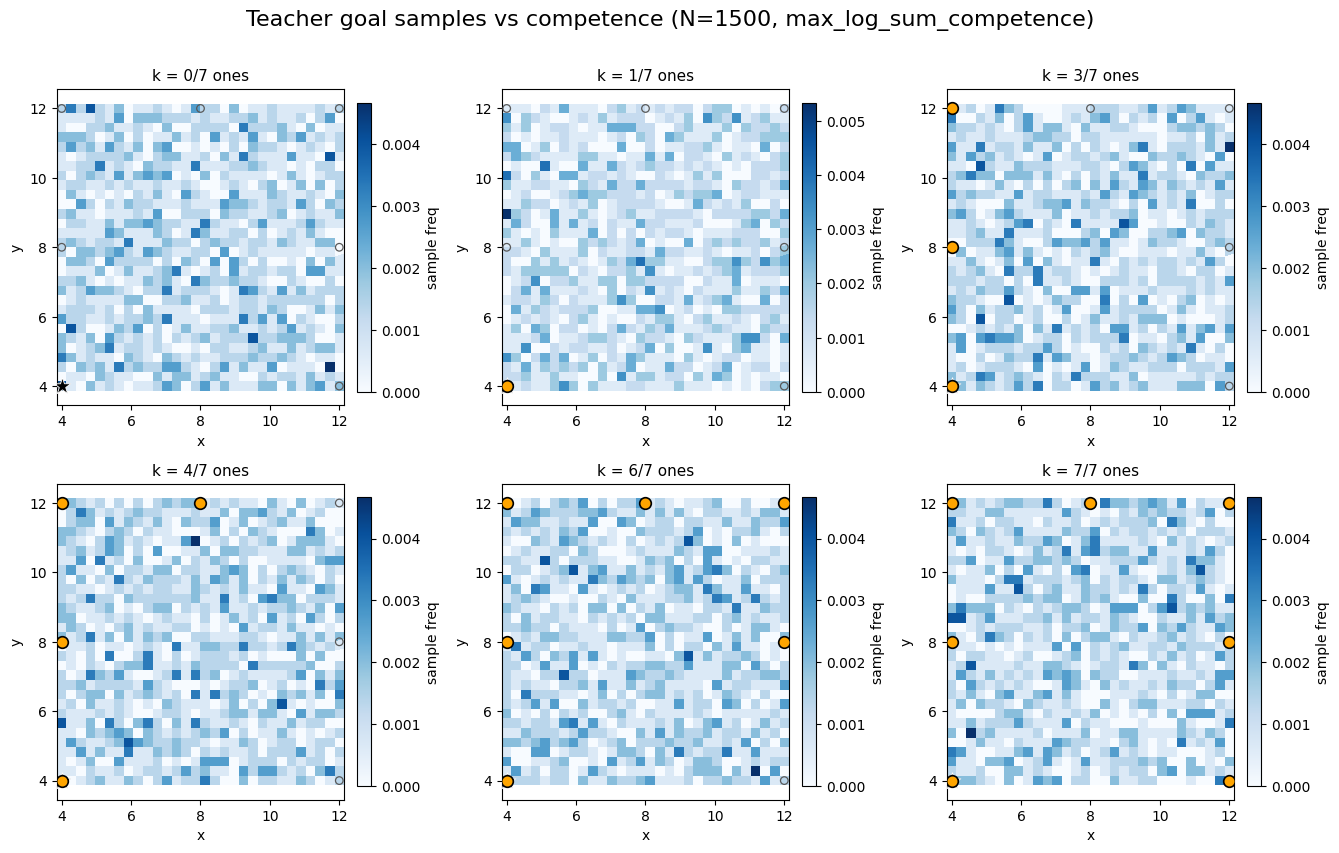

In [21]:
samples_fig = render_context_sweep_figure(
    sample_freqs, colorbar_label="sample freq",
    suptitle=f"Teacher goal samples vs competence (N={NUM_SAMPLES}, {CHECKPOINT})",
)
plt.show()

## KL divergences

KL vs c=0: min=0 max=1.487e-06 mean=7.896e-07


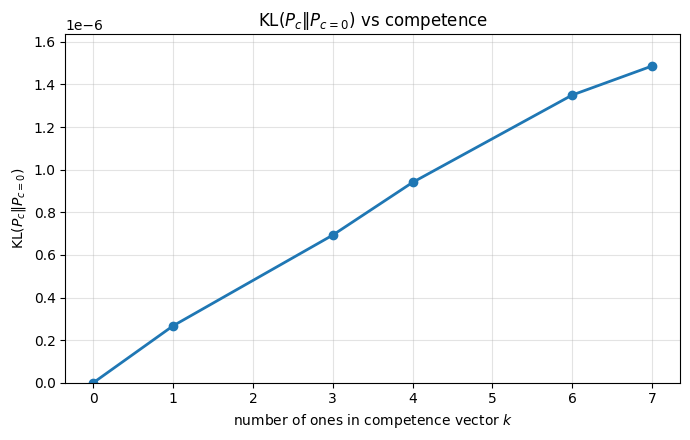

In [22]:
def pairwise_kl_matrix(probs, eps=1e-12):
    """``M[i, j] = KL(P_i || P_j)`` for rows of ``probs``."""
    p = np.clip(np.asarray(probs, dtype=np.float64), eps, None)
    p = p / p.sum(axis=-1, keepdims=True)
    log_p = np.log(p)
    return np.maximum(np.sum(p * log_p, axis=-1)[:, None] - p @ log_p.T, 0.0)


def rowwise_kl(p_probs, q_probs, eps=1e-12):
    """``KL(P_i || Q_i)`` for matching rows of ``p_probs`` and ``q_probs``."""
    p = np.clip(np.asarray(p_probs, dtype=np.float64), eps, None)
    q = np.clip(np.asarray(q_probs, dtype=np.float64), eps, None)
    p = p / p.sum(axis=-1, keepdims=True)
    q = q / q.sum(axis=-1, keepdims=True)
    return np.maximum(np.sum(p * (np.log(p) - np.log(q)), axis=-1), 0.0)


def plot_kl_vs_zero(kl_vs_zero, *, title_suffix=""):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    ax.plot(ks, kl_vs_zero, marker="o", linewidth=2.0, markersize=6)
    ax.set_xlabel("number of ones in competence vector $k$")
    ax.set_ylabel(r"KL$(P_c \| P_{c=0})$")
    ax.set_title(r"KL$(P_c \| P_{c=0})$ vs competence" + title_suffix)
    ax.grid(True, alpha=0.35)
    ax.set_ylim(bottom=0.0, top=max(float(kl_vs_zero.max()) * 1.1, 1e-6))
    fig.tight_layout()
    return fig


kl_matrix = pairwise_kl_matrix(probs)
# Context 0 is the all-zero competence vector.
kl_vs_zero = kl_matrix[:, 0]
print(
    f"KL vs c=0: min={kl_vs_zero.min():.4g} max={kl_vs_zero.max():.4g} "
    f"mean={kl_vs_zero.mean():.4g}"
)
kl_fig = plot_kl_vs_zero(kl_vs_zero)
plt.show()


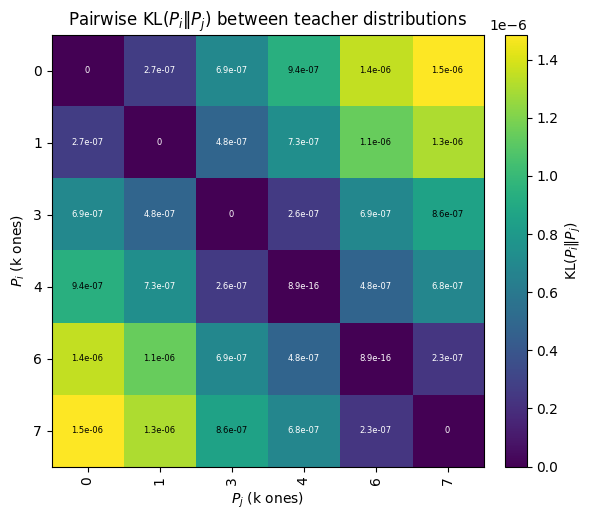

In [23]:
def plot_pairwise_kl(kl_matrix, *, title_suffix=""):
    num_ctx = len(ks)
    fig, ax = plt.subplots(figsize=(0.55 * num_ctx + 3.0, 0.55 * num_ctx + 2.0))
    im = ax.imshow(kl_matrix, cmap="viridis", origin="upper")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r"KL$(P_i \| P_j)$")
    ax.set_xticks(range(num_ctx))
    ax.set_yticks(range(num_ctx))
    ax.set_xticklabels(ks.tolist(), rotation=90)
    ax.set_yticklabels(ks.tolist())
    ax.set_xlabel("$P_j$ (k ones)")
    ax.set_ylabel("$P_i$ (k ones)")
    ax.set_title(r"Pairwise KL$(P_i \| P_j)$ between teacher distributions" + title_suffix)
    if num_ctx <= 16:
        threshold = 0.5 * float(kl_matrix.max())
        for i in range(num_ctx):
            for j in range(num_ctx):
                ax.text(
                    j, i, f"{kl_matrix[i, j]:.2g}", ha="center", va="center", fontsize=6,
                    color="black" if kl_matrix[i, j] > threshold else "white",
                )
    fig.tight_layout()
    return fig


kl_matrix_fig = plot_pairwise_kl(kl_matrix)
plt.show()


## Distilled teacher

Same competence sweep for the distilled teacher, and KL$(P_{RL} \| P_{distilled})$
per competence vector.

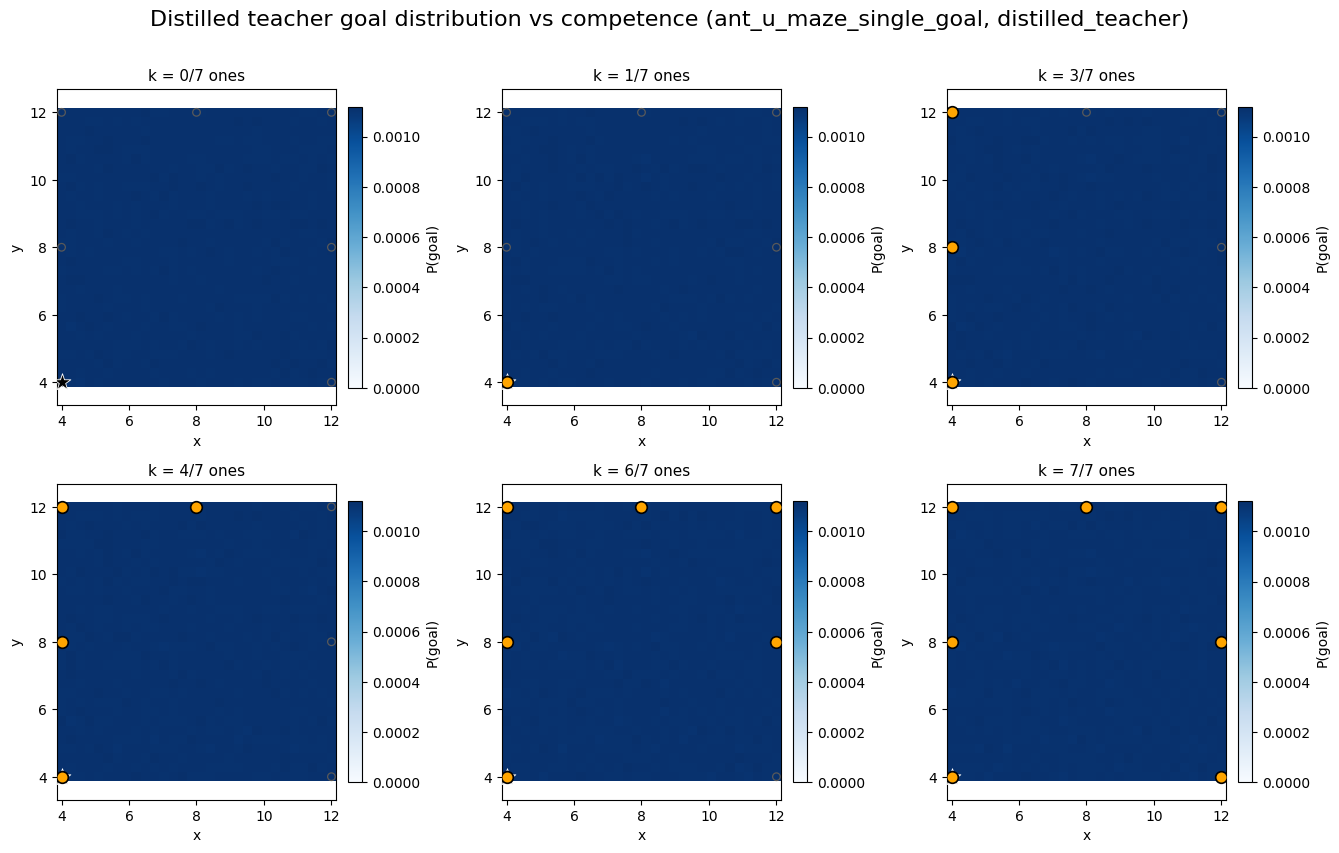

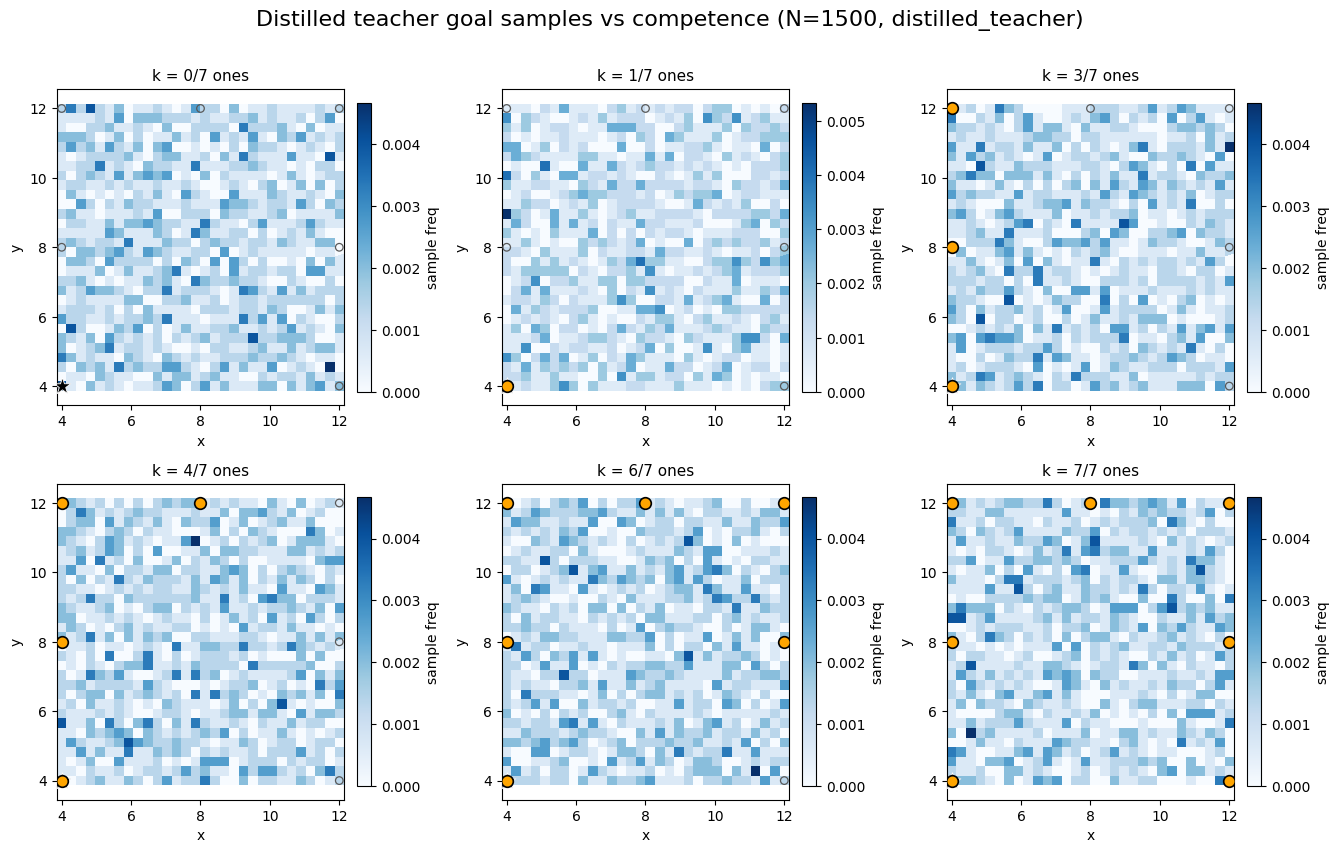

In [24]:
distilled_probs_fig = distilled_samples_fig = None
if distilled_probs is not None:
    distilled_probs_fig = render_context_sweep_figure(
        distilled_probs, colorbar_label="P(goal)",
        suptitle=f"Distilled teacher goal distribution vs competence ({config['ENV_NAME']}, {DISTILLED_SUBDIR})",
    )
    plt.show()
    distilled_samples_fig = render_context_sweep_figure(
        distilled_sample_freqs, colorbar_label="sample freq",
        suptitle=f"Distilled teacher goal samples vs competence (N={NUM_SAMPLES}, {DISTILLED_SUBDIR})",
    )
    plt.show()


KL(RL || distilled): min=3.873e-07 max=2.287e-06 mean=1.218e-06


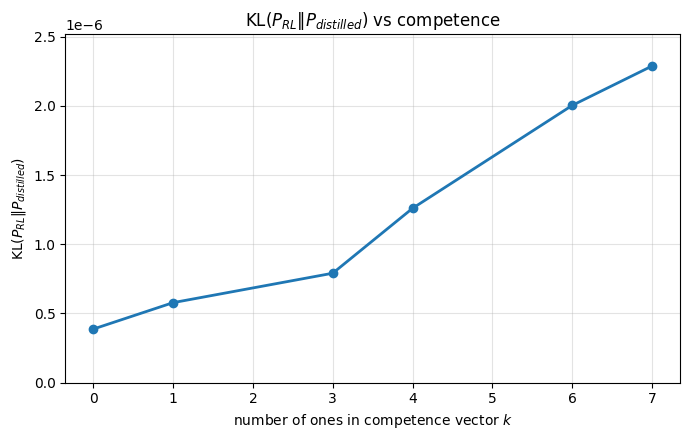

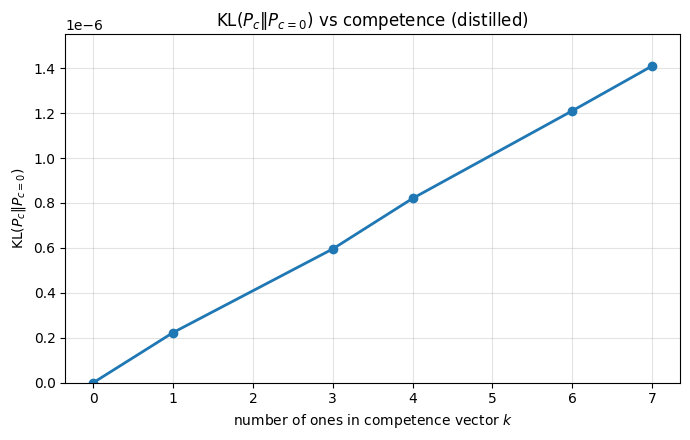

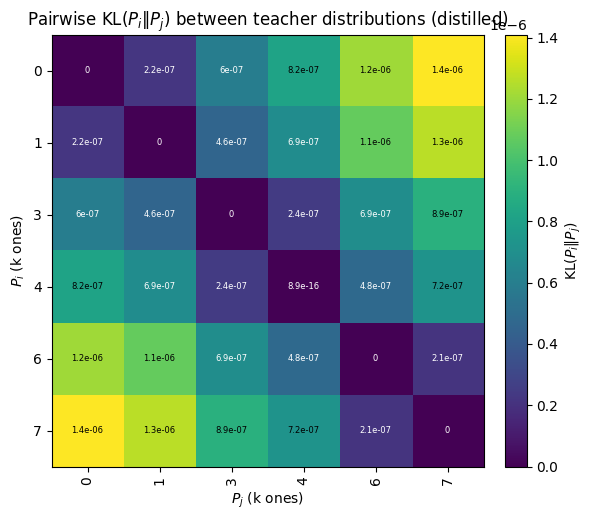

In [25]:
kl_rl_vs_distilled = None
kl_rl_vs_distilled_fig = None
distilled_kl_matrix = distilled_kl_vs_zero = None
distilled_kl_fig = distilled_kl_matrix_fig = None
if distilled_probs is not None:
    kl_rl_vs_distilled = rowwise_kl(probs, distilled_probs)
    print(
        f"KL(RL || distilled): min={kl_rl_vs_distilled.min():.4g} "
        f"max={kl_rl_vs_distilled.max():.4g} mean={kl_rl_vs_distilled.mean():.4g}"
    )
    kl_rl_vs_distilled_fig, ax = plt.subplots(figsize=(7.0, 4.5))
    ax.plot(ks, kl_rl_vs_distilled, marker="o", linewidth=2.0, markersize=6)
    ax.set_xlabel("number of ones in competence vector $k$")
    ax.set_ylabel(r"KL$(P_{RL} \| P_{distilled})$")
    ax.set_title(r"KL$(P_{RL} \| P_{distilled})$ vs competence")
    ax.grid(True, alpha=0.35)
    ax.set_ylim(bottom=0.0, top=max(float(kl_rl_vs_distilled.max()) * 1.1, 1e-6))
    kl_rl_vs_distilled_fig.tight_layout()
    plt.show()

    distilled_kl_matrix = pairwise_kl_matrix(distilled_probs)
    distilled_kl_vs_zero = distilled_kl_matrix[:, 0]
    distilled_kl_fig = plot_kl_vs_zero(distilled_kl_vs_zero, title_suffix=" (distilled)")
    plt.show()
    distilled_kl_matrix_fig = plot_pairwise_kl(distilled_kl_matrix, title_suffix=" (distilled)")
    plt.show()


## Save

In [ ]:
if SAVE_FIGURES:
    output_dir = OUTPUT_DIR or os.path.join(EXP_DIR, "teacher_context_sweep")
    os.makedirs(output_dir, exist_ok=True)
    figures = {
        f"teacher_goal_distribution_contexts_{CHECKPOINT}.png": probs_fig,
        f"teacher_goal_samples_contexts_{CHECKPOINT}.png": samples_fig,
        f"teacher_kl_vs_zero_competence_{CHECKPOINT}.png": kl_fig,
        f"teacher_pairwise_kl_{CHECKPOINT}.png": kl_matrix_fig,
    }
    for name, fig in figures.items():
        fig.savefig(os.path.join(output_dir, name), dpi=200, bbox_inches="tight")
    npz_path = os.path.join(output_dir, f"teacher_goal_distribution_contexts_{CHECKPOINT}.npz")
    np.savez(
        npz_path,
        probs=probs,
        sample_counts=sample_counts,
        sample_freqs=sample_freqs,
        num_samples=np.asarray(NUM_SAMPLES),
        contexts=contexts,
        ks=ks,
        order=order,
        goal_bfs_dists=goal_bfs_dists,
        kl_vs_zero=kl_vs_zero,
        kl_matrix=kl_matrix,
        goal_grid=goal_grid,
        competence_goals=competence_goals,
        start_xy=start_xy,
        competence_vector_scale=np.asarray(competence_vector_scale),
    )
    if distilled_probs is not None:
        distilled_figures = {
            f"teacher_goal_distribution_contexts_{CHECKPOINT}_distilled.png": distilled_probs_fig,
            f"teacher_goal_samples_contexts_{CHECKPOINT}_distilled.png": distilled_samples_fig,
            f"teacher_kl_rl_vs_distilled_{CHECKPOINT}_distilled.png": kl_rl_vs_distilled_fig,
            f"teacher_kl_vs_zero_competence_{CHECKPOINT}_distilled.png": distilled_kl_fig,
            f"teacher_pairwise_kl_{CHECKPOINT}_distilled.png": distilled_kl_matrix_fig,
        }
        for name, fig in distilled_figures.items():
            fig.savefig(os.path.join(output_dir, name), dpi=200, bbox_inches="tight")
        np.savez(
            os.path.join(output_dir, f"teacher_goal_distribution_contexts_{CHECKPOINT}_distilled.npz"),
            distilled_subdir=np.asarray(DISTILLED_SUBDIR),
            distilled_only_competence_input=np.asarray(distill_cfg["only_competence_input"]),
            distilled_probs=distilled_probs,
            distilled_sample_counts=distilled_sample_counts,
            distilled_sample_freqs=distilled_sample_freqs,
            kl_rl_vs_distilled=kl_rl_vs_distilled,
            distilled_kl_vs_zero=distilled_kl_vs_zero,
            distilled_kl_matrix=distilled_kl_matrix,
            contexts=contexts,
            ks=ks,
        )
    print(f"saved figures and arrays to {output_dir}")